In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 25.4 MB/s eta 0:00:00


In [7]:
import numpy as np
import math
import pandas as pd
import glob
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [8]:



datasetPath = "nyc-taxi-drift-forecasting/data/raw/merged_file.parquet"


df = pd.read_parquet(datasetPath)



In [9]:
df.size

974452040

In [10]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [11]:
for column in df.columns:
  print("Column Name: " + str(column) + ", Type: " + str(df[column].dtype))

Column Name: VendorID, Type: int32
Column Name: tpep_pickup_datetime, Type: datetime64[us]
Column Name: tpep_dropoff_datetime, Type: datetime64[us]
Column Name: passenger_count, Type: float64
Column Name: trip_distance, Type: float64
Column Name: RatecodeID, Type: float64
Column Name: store_and_fwd_flag, Type: object
Column Name: PULocationID, Type: int32
Column Name: DOLocationID, Type: int32
Column Name: payment_type, Type: int64
Column Name: fare_amount, Type: float64
Column Name: extra, Type: float64
Column Name: mta_tax, Type: float64
Column Name: tip_amount, Type: float64
Column Name: tolls_amount, Type: float64
Column Name: improvement_surcharge, Type: float64
Column Name: total_amount, Type: float64
Column Name: congestion_surcharge, Type: float64
Column Name: Airport_fee, Type: float64
Column Name: cbd_congestion_fee, Type: float64


In [12]:
df.isna().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,11611894
trip_distance,0
RatecodeID,11611894
store_and_fwd_flag,11611894
PULocationID,0
DOLocationID,0
payment_type,0


In [13]:
n = df[df['Airport_fee'].isna()]
print(n.head())

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
3109524         2  2025-12-01 00:10:03   2025-12-01 00:22:17              NaN   
3109525         2  2025-12-01 00:15:55   2025-12-01 00:22:06              NaN   
3109526         2  2025-12-01 00:53:26   2025-12-01 01:05:05              NaN   
3109527         2  2025-12-01 00:50:32   2025-12-01 01:06:58              NaN   
3109528         2  2025-12-01 00:03:03   2025-12-01 00:16:22              NaN   

         trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
3109524           2.55         NaN               None            75   
3109525           1.11         NaN               None           140   
3109526           2.97         NaN               None           140   
3109527           9.11         NaN               None           191   
3109528           2.08         NaN               None           230   

         DOLocationID  payment_type  fare_amount  extra  mta_tax  tip_amount  \
310952

Will Not Drop the Empty Rows even though they only take about 1.2% of Dataset, As I can still use those rows when I aggregate for certain columns and the NA ones I will just use the average

(array([1540194., 1015732.,  668371.,  457073.,  360923.,  385453.,
         758797., 1383178., 1869222., 1998754., 2083263., 2234450.,
        2435176., 2553786., 2740931., 2854120., 2934914., 3291155.,
        3473210., 3071607., 2826127., 2901042., 2730170., 2154954.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.]),
 <BarContainer object of 24 artists>)

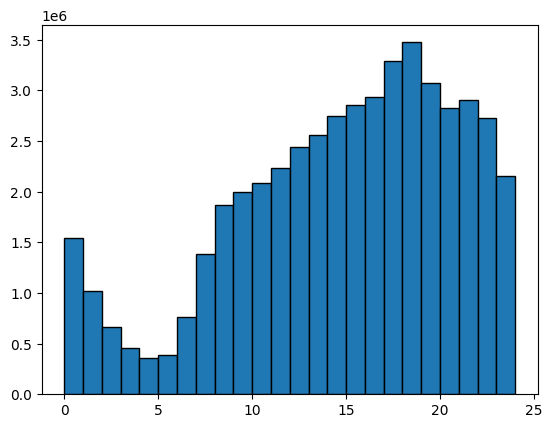

In [14]:
#group the number of taxi calls by hour and look at the histogram
plt.hist(df['tpep_pickup_datetime'].dt.hour, bins=24, range=(0, 24), edgecolor='black')

(np.float64(20088.0), np.float64(20453.0))

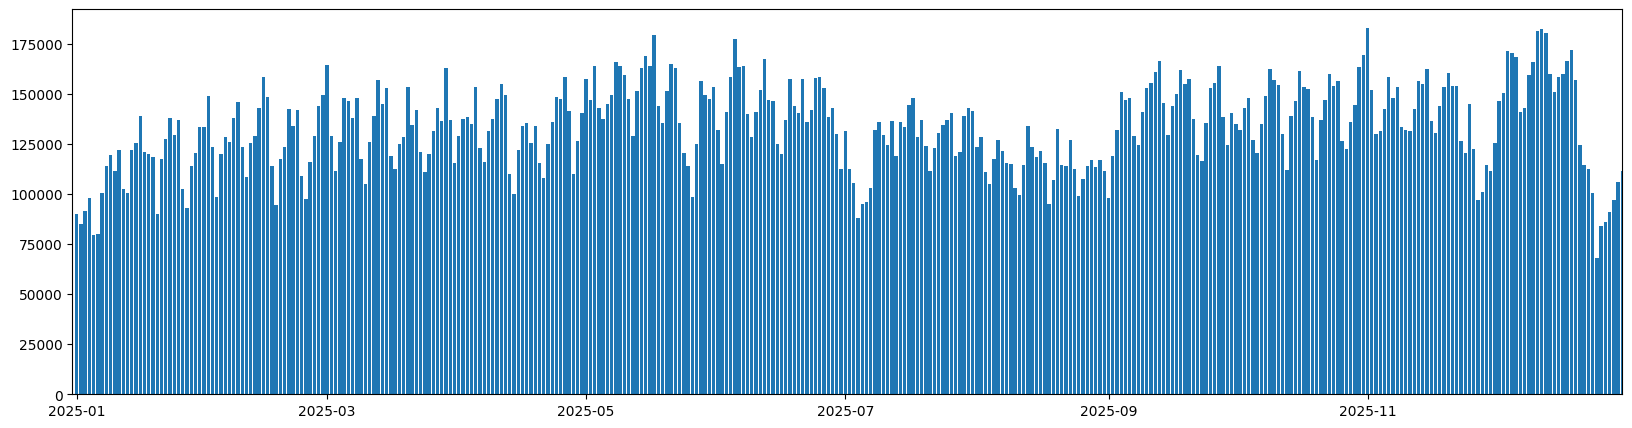

In [15]:
# Count observations per day
daily_counts = df['tpep_pickup_datetime'].dt.date.value_counts().sort_index()
plt.figure(figsize=(20, 5))
plt.bar(daily_counts.index, daily_counts.values)
# Fix: limit x-axis to your actual data range
plt.xlim(pd.Timestamp('2024-12-31'), daily_counts.index.max())

(np.float64(20301.0), np.float64(20453.0))

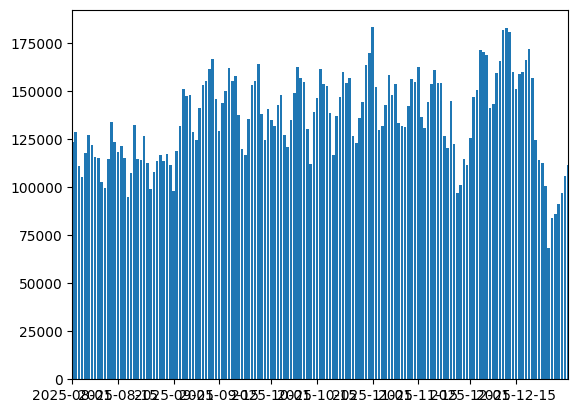

In [16]:
plt.bar(daily_counts.index, daily_counts.values)
plt.xlim(pd.Timestamp('2025-08-01'), daily_counts.index.max())

In [17]:
daily_counts.index.min()

datetime.date(2007, 12, 5)

<BarContainer object of 10 artists>

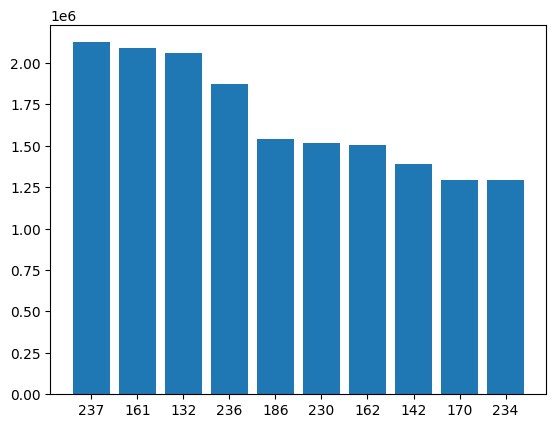

In [18]:


top10PU = df['PULocationID'].value_counts().head(10)

plt.bar(top10PU.index.astype(str), top10PU.values)




237- Upper East Side South Manhattan
132 - Queens JFK Airport
161 - Manhattan Midtown Center
236 - Manhattan Upper East Side North
186 - Manhattan Penn Station/Madison Sq West
162 - Manhattan Midtown East

<BarContainer object of 10 artists>

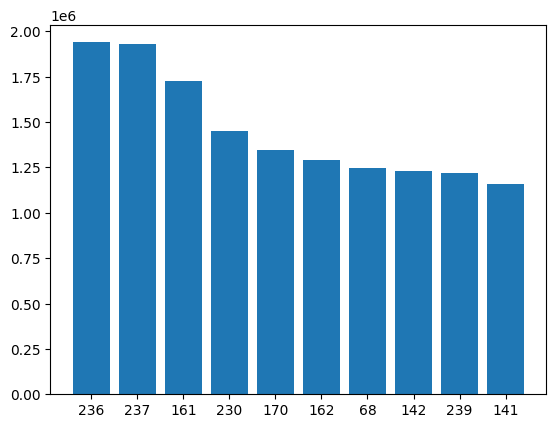

In [19]:
top10DO = df['DOLocationID'].value_counts().head(10)

plt.bar(top10DO.index.astype(str), top10DO.values)

Graphs & Visualizations

(array([1.1611894e+07, 0.0000000e+00, 3.1054000e+07, 0.0000000e+00,
        4.6543450e+06, 0.0000000e+00, 3.0814700e+05, 0.0000000e+00,
        1.0942130e+06, 3.0000000e+00]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

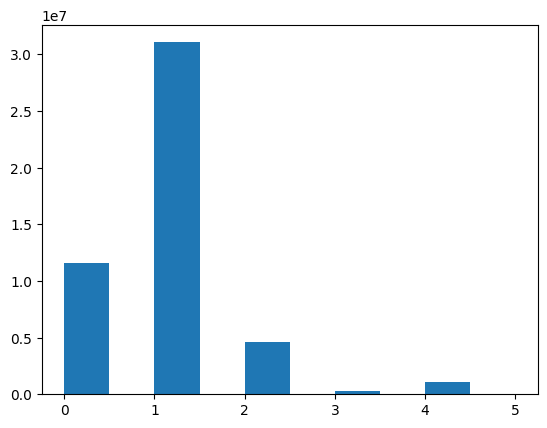

In [20]:
plt.hist(df['payment_type'])

In [21]:
df = pl.from_pandas(df)
print(type(df))

<class 'polars.dataframe.frame.DataFrame'>


In [22]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
aggregated_df = (
    df
    # 1. Truncate the datetime column directly to the hour mark
    .with_columns(
        pl.col('tpep_pickup_datetime').dt.truncate('1h')
    )
    # 2. Group by the truncated hour and zone
    .group_by(['tpep_pickup_datetime', 'PULocationID'])
    .agg([
        pl.len().alias('trip_count')


    ])
    # 3. Create the descriptive columns from the grouped timestamp
    .with_columns([
        pl.col('tpep_pickup_datetime').dt.hour().alias('hour'),
        pl.col('tpep_pickup_datetime').dt.strftime('%A').alias('day_of_week'),
        pl.col('tpep_pickup_datetime').dt.day().alias('day_of_month'),
        pl.col('tpep_pickup_datetime').dt.year().alias('year'),
        pl.col('tpep_pickup_datetime').dt.month().alias('month'),
        pl.col('tpep_pickup_datetime').dt.weekday().is_in([6, 7]).alias('is_weekend')
    ])
)

aggregated_df = aggregated_df.with_columns(
    pl.col("day_of_week")
    .cast(pl.Enum(weekday_order))
    .alias("day_factor")
)
aggregated_df = aggregated_df.drop("day_of_week")

In [23]:
aggregated_df.head()

tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor
datetime[μs],i32,u32,i8,i8,i32,i8,bool,enum
2025-02-16 14:00:00,95,2,14,16,2025,2,true,"""Sunday"""
2025-04-28 03:00:00,18,2,3,28,2025,4,false,"""Monday"""
2025-06-28 20:00:00,137,76,20,28,2025,6,true,"""Saturday"""
2025-06-09 13:00:00,239,203,13,9,2025,6,false,"""Monday"""
2025-04-16 14:00:00,132,344,14,16,2025,4,false,"""Wednesday"""


In [24]:
aggregated_df.shape

(1430300, 9)

In [25]:
ram = aggregated_df.estimated_size('mb')
print(ram)

32.907474517822266


In [26]:
print(df.estimated_size('mb'))

6563.793460845947


In [27]:
df_sorted = aggregated_df.sort("tpep_pickup_datetime")
df_sorted.head(10)

tpep_pickup_datetime,PULocationID,trip_count,hour,day_of_month,year,month,is_weekend,day_factor
datetime[μs],i32,u32,i8,i8,i32,i8,bool,enum
2007-12-05 18:00:00,142,1,18,5,2007,12,false,"""Wednesday"""
2008-12-31 23:00:00,132,1,23,31,2008,12,false,"""Wednesday"""
2009-01-01 00:00:00,230,1,0,1,2009,1,false,"""Thursday"""
2009-01-01 00:00:00,138,1,0,1,2009,1,false,"""Thursday"""
2009-01-01 00:00:00,239,1,0,1,2009,1,false,"""Thursday"""
2009-01-01 08:00:00,138,1,8,1,2009,1,false,"""Thursday"""
2009-01-01 12:00:00,43,1,12,1,2009,1,false,"""Thursday"""
2009-01-01 14:00:00,138,1,14,1,2009,1,false,"""Thursday"""
2024-12-31 20:00:00,246,1,20,31,2024,12,false,"""Tuesday"""


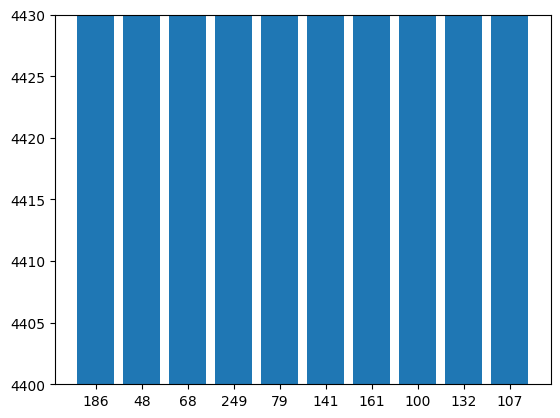

In [28]:
top10PU = df_sorted['PULocationID'].value_counts().sort("count", descending=True).head(10)
plt.bar(top10PU['PULocationID'].cast(pl.String), top10PU['count'])
plt.ylim(4400, 4430)

plt.show()


<Axes: >

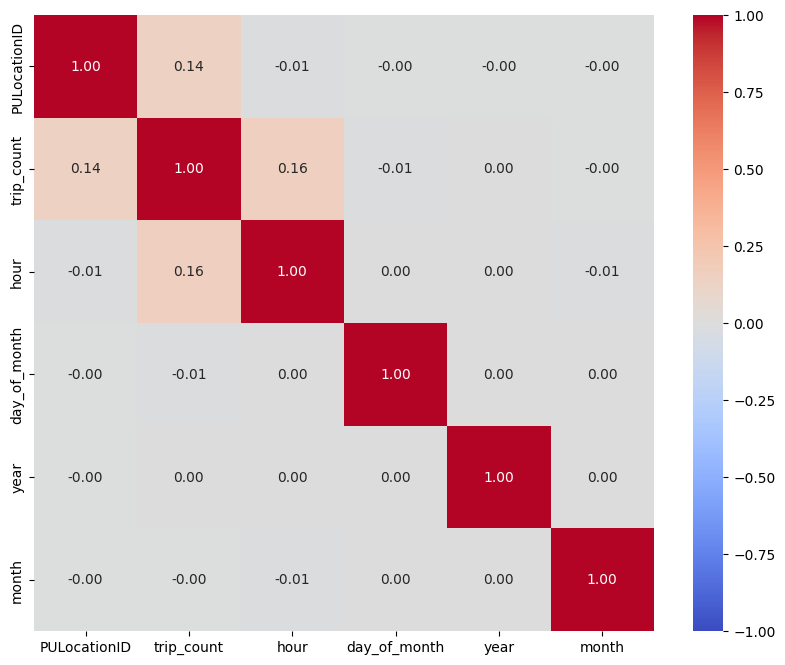

In [29]:

# Select only numeric columns
numeric_cols = [col for col, dtype in zip(df_sorted.columns, df_sorted.dtypes)
                if dtype in [pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                             pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                             pl.Float32, pl.Float64]]

corr = df_sorted.select(numeric_cols).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,        # show numbers
            fmt='.2f',         # 2 decimal places
            cmap='coolwarm',   # color scheme
            vmin=-1, vmax=1)   # fix scale to -1 to 1

Text(0.5, 1.0, 'Trip Counts vs Location IDs')

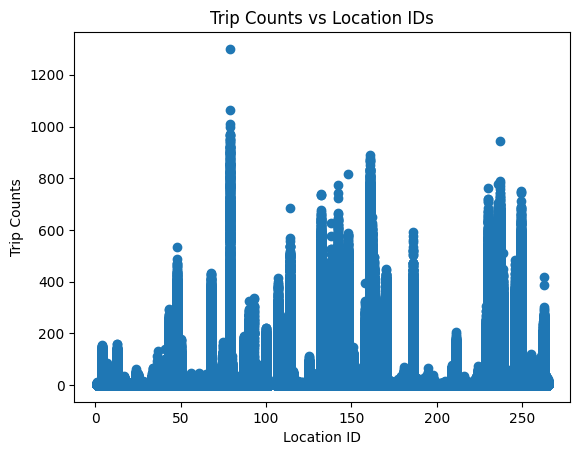

In [30]:
#Plotting Trip Count vs Location ID

plt.scatter(df_sorted['PULocationID'], df_sorted['trip_count'])
plt.xlabel("Location ID")
plt.ylabel("Trip Counts")
plt.title("Trip Counts vs Location IDs")

In [31]:
result = (df_sorted
    .group_by('PULocationID')
    .agg(pl.col('trip_count').sum())
    .sort('trip_count', descending=True))

result

PULocationID,trip_count
i32,u32
237,2125560
161,2089754
132,2062456
236,1874807
186,1543166
…,…
204,29
5,20
199,18


In [32]:
df_sorted = df_sorted.filter(pl.col('year') >= 2025)

Text(0.5, 1.0, 'Trip Counts vs Location IDs')

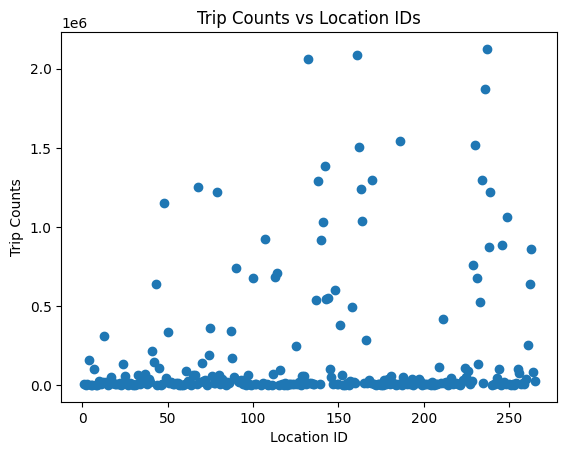

In [33]:
#Plotting Trip Count vs Location ID

plt.scatter(result['PULocationID'], result['trip_count'])
plt.xlabel("Location ID")
plt.ylabel("Trip Counts")
plt.title("Trip Counts vs Location IDs")

In [34]:
df_sorted.write_csv("/content/drive/MyDrive/Colab Notebooks/nyc-taxi-drift-forecasting/data/aggregatedData.csv")